In [41]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification

x, y = make_classification(n_features=5, n_redundant=0, n_informative=5, n_clusters_per_class=1)

In [42]:
df = pd.DataFrame(x, columns=['col1', 'col2', 'col3', 'col4', 'col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,-2.320092,1.611934,0.231434,-0.066396,-1.391951,0
1,2.901093,0.747242,-0.924893,-1.209472,-1.084598,1
2,-3.972757,3.530005,0.166623,-0.466209,-1.975429,0
3,2.584589,0.188971,-0.642670,-3.636948,-0.822914,1
4,1.102110,-1.162088,1.673664,-0.918998,-1.725413,1


In [43]:
def sample_rows(df, percent):
    return df.sample(int(percent*df.shape[0]), replace=True)

In [57]:
import random
def sample_features(df, percent):
    cols = random.sample(df.columns.tolist()[:-1], int(percent*(df.shape[1] -1)))
    new_df = df[cols]
    new_df['target'] = df['target']
    return new_df

In [45]:
def sample_combined(df, row_percent, col_percent):
    return (df.sample(int(row_percent*df.shape[0]), replace=True)).sample(int(col_percent*df.shape[1]), replace=True, axis=1)

In [46]:
df1 = sample_rows(df, 0.1)
df2 = sample_rows(df, 0.1)
df3 = sample_rows(df, 0.1)

In [47]:
from sklearn.tree import DecisionTreeClassifier
clf1  = DecisionTreeClassifier()
clf2  = DecisionTreeClassifier()
clf3  = DecisionTreeClassifier()

In [48]:
clf1.fit(df1.iloc[:, 0:5], df1.iloc[:, -1])
clf2.fit(df2.iloc[:, 0:5], df2.iloc[:, -1])
clf3.fit(df3.iloc[:, 0:5], df3.iloc[:, -1])

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

[Text(0.4, 0.8333333333333334, 'x[1] <= -0.029\ngini = 0.48\nsamples = 10\nvalue = [4, 6]'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'x[3] <= 0.998\ngini = 0.32\nsamples = 5\nvalue = [4, 1]'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.8, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]')]

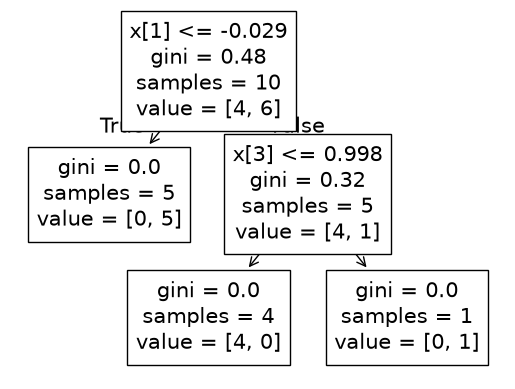

In [49]:
from sklearn.tree import plot_tree
plot_tree(clf1)

[Text(0.4, 0.8333333333333334, 'x[0] <= -0.981\ngini = 0.48\nsamples = 10\nvalue = [6, 4]'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'x[3] <= -1.769\ngini = 0.32\nsamples = 5\nvalue = [1, 4]'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.8, 0.16666666666666666, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]')]

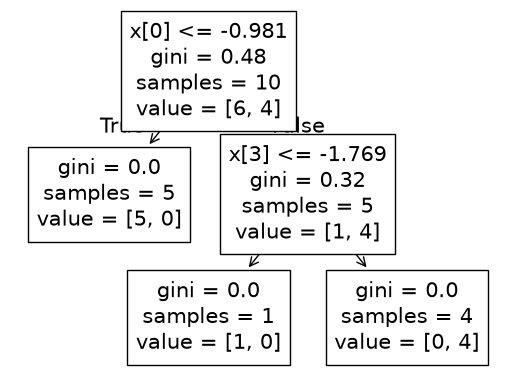

In [50]:
plot_tree(clf2)

[Text(0.3333333333333333, 0.875, 'x[0] <= -0.589\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.16666666666666666, 0.625, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.25, 0.75, 'True  '),
 Text(0.5, 0.625, 'x[2] <= 3.173\ngini = 0.278\nsamples = 6\nvalue = [1, 5]'),
 Text(0.41666666666666663, 0.75, '  False'),
 Text(0.3333333333333333, 0.375, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.6666666666666666, 0.375, 'x[3] <= -2.187\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.5, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.8333333333333334, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]')]

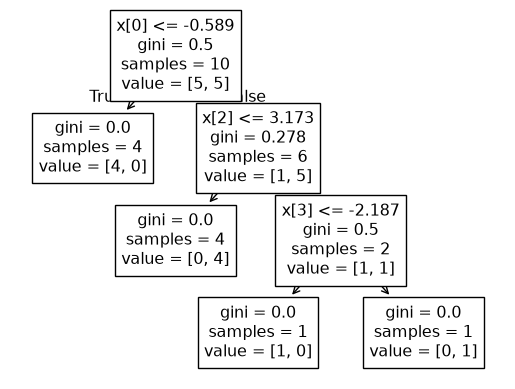

In [51]:
plot_tree(clf3)

In [60]:
df1 = sample_features(df, 0.8)
df2 = sample_features(df, 0.8)
df3 = sample_features(df, 0.8)

C:\Users\Tanmay\AppData\Local\Temp\ipykernel_22352\3983860197.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']
C:\Users\Tanmay\AppData\Local\Temp\ipykernel_22352\3983860197.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']
C:\Users\Tanmay\AppData\Local\Temp\ipykernel_22352\3983860197.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See

In [61]:
clf1.fit(df1.iloc[:, 0:3], df1.iloc[:, -1])
clf2.fit(df2.iloc[:, 0:3], df2.iloc[:, -1])
clf3.fit(df3.iloc[:, 0:3], df3.iloc[:, -1])

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

[Text(0.5769230769230769, 0.9444444444444444, 'x[0] <= -0.261\ngini = 0.5\nsamples = 100\nvalue = [49, 51]'),
 Text(0.3076923076923077, 0.8333333333333334, 'x[1] <= 0.295\ngini = 0.305\nsamples = 48\nvalue = [39, 9]'),
 Text(0.4423076923076923, 0.8888888888888888, 'True  '),
 Text(0.19230769230769232, 0.7222222222222222, 'x[0] <= -0.694\ngini = 0.24\nsamples = 43\nvalue = [37, 6]'),
 Text(0.07692307692307693, 0.6111111111111112, 'x[2] <= 0.52\ngini = 0.111\nsamples = 34\nvalue = [32, 2]'),
 Text(0.038461538461538464, 0.5, 'gini = 0.0\nsamples = 21\nvalue = [21, 0]'),
 Text(0.11538461538461539, 0.5, 'x[2] <= 0.658\ngini = 0.26\nsamples = 13\nvalue = [11, 2]'),
 Text(0.07692307692307693, 0.3888888888888889, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.15384615384615385, 0.3888888888888889, 'x[1] <= -1.735\ngini = 0.153\nsamples = 12\nvalue = [11, 1]'),
 Text(0.11538461538461539, 0.2777777777777778, 'x[2] <= 1.544\ngini = 0.444\nsamples = 3\nvalue = [2, 1]'),
 Text(0.07692307692307

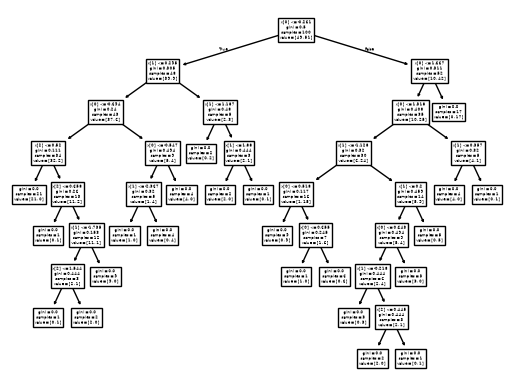

In [62]:
plot_tree(clf1)

[Text(0.375, 0.9375, 'x[0] <= -0.173\ngini = 0.5\nsamples = 100\nvalue = [49, 51]'),
 Text(0.14, 0.8125, 'x[0] <= -1.479\ngini = 0.24\nsamples = 43\nvalue = [6, 37]'),
 Text(0.2575, 0.875, 'True  '),
 Text(0.1, 0.6875, 'gini = 0.0\nsamples = 18\nvalue = [0, 18]'),
 Text(0.18, 0.6875, 'x[2] <= -1.589\ngini = 0.365\nsamples = 25\nvalue = [6, 19]'),
 Text(0.08, 0.5625, 'x[1] <= 0.335\ngini = 0.49\nsamples = 7\nvalue = [4, 3]'),
 Text(0.04, 0.4375, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.12, 0.4375, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.28, 0.5625, 'x[2] <= 0.594\ngini = 0.198\nsamples = 18\nvalue = [2, 16]'),
 Text(0.2, 0.4375, 'x[1] <= 1.848\ngini = 0.124\nsamples = 15\nvalue = [1, 14]'),
 Text(0.16, 0.3125, 'gini = 0.0\nsamples = 10\nvalue = [0, 10]'),
 Text(0.24, 0.3125, 'x[1] <= 2.135\ngini = 0.32\nsamples = 5\nvalue = [1, 4]'),
 Text(0.2, 0.1875, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.28, 0.1875, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text

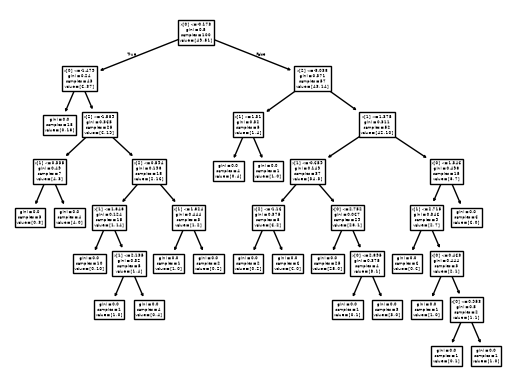

In [63]:
plot_tree(clf2)

[Text(0.5769230769230769, 0.9444444444444444, 'x[2] <= -0.261\ngini = 0.5\nsamples = 100\nvalue = [49, 51]'),
 Text(0.3076923076923077, 0.8333333333333334, 'x[1] <= 0.295\ngini = 0.305\nsamples = 48\nvalue = [39, 9]'),
 Text(0.4423076923076923, 0.8888888888888888, 'True  '),
 Text(0.19230769230769232, 0.7222222222222222, 'x[2] <= -0.694\ngini = 0.24\nsamples = 43\nvalue = [37, 6]'),
 Text(0.07692307692307693, 0.6111111111111112, 'x[0] <= 0.52\ngini = 0.111\nsamples = 34\nvalue = [32, 2]'),
 Text(0.038461538461538464, 0.5, 'gini = 0.0\nsamples = 21\nvalue = [21, 0]'),
 Text(0.11538461538461539, 0.5, 'x[0] <= 0.658\ngini = 0.26\nsamples = 13\nvalue = [11, 2]'),
 Text(0.07692307692307693, 0.3888888888888889, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.15384615384615385, 0.3888888888888889, 'x[1] <= -1.735\ngini = 0.153\nsamples = 12\nvalue = [11, 1]'),
 Text(0.11538461538461539, 0.2777777777777778, 'x[1] <= -2.065\ngini = 0.444\nsamples = 3\nvalue = [2, 1]'),
 Text(0.0769230769230

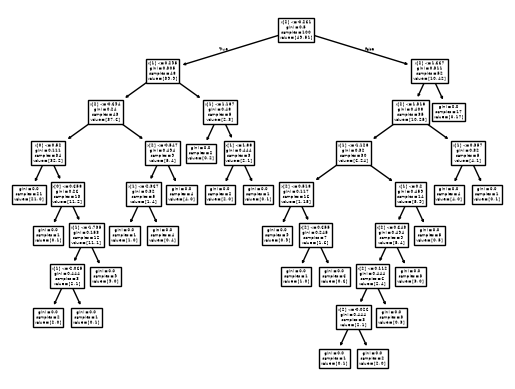

In [64]:
plot_tree(clf3)